# Flow of a Darcy fluid injected and extracted in a porous rectangle

$$
\mathbb{S}_{\mathbf{u},p}
\begin{cases}
\Omega = [0, L_x] \times [0, L_y] \\
\mathsf{K}(y)=K(x,y)\mathsf{I} & \text{keterogeneous permeability}  \\
\mu = 1 & \text{constant viscosity} \\
u_{\text{E}}(x,y=0) = u_{\mathrm{in}}e^{-(x-x_{\mathrm{in}})^2/\sigma^2} - u_{\mathrm{in}}e^{-(x-x_{\mathrm{out}})^2/\sigma^2} & \text{inflow and outflow on lower boundary} \\
u_{\text{E}}(x=0,y) = 0 & \text{no-penetration on left boundary} \\
u_{\text{E}}(x=L_x,y) = 0 & \text{no-penetration on right boundary} \\
u_{\text{E}}(x,y=L_y) = 0 & \text{no-penetration on upper boundary} \\
\end{cases}
$$

In [1]:
import numpy as np
from lucifex.mesh import rectangle_mesh, mesh_boundary
from lucifex.fem import Function, Constant
from lucifex.solver import bvp, BoundaryConditions, OptionsPETSc
from lucifex.utils.fenicsx_utils import extract_component_functions
from lucifex.viz import plot_colormap, plot_streamlines, save_figure
from lucifex.pde.darcy import darcy

Lx = 5.0
Ly = 1.0
Nx = 30
Ny = 30
mesh = rectangle_mesh(Lx, Ly, Nx, Ny, cell='right')
boundary = mesh_boundary(
    mesh, 
    {
        "left": lambda x: x[0],
        "right": lambda x: x[0] - Lx,
        "lower": lambda x: x[1],
        "upper": lambda x: x[1] - Ly,
    },
)

mu = Constant(mesh, 1.0, 'mu')

u_deg = 1
u_elem = ('BDM', u_deg)
p_elem = ('DP', u_deg - 1)
u_p_elem = [u_elem, p_elem]


xIn = 0.25 * Lx
xOut = 0.75 * Lx
uIn = 1.0
uStd = 0.1 * Lx
uLower = lambda x: (
    uIn * np.exp(-((xIn - x[0]) / uStd)**2) 
    - uIn * np.exp(-((xOut - x[0]) / uStd)**2)
)
u_bcs = BoundaryConditions(
    ('essential', boundary['left', 'right', 'upper'], (0.0, 0.0), 0),
    ('essential', boundary['lower'], (0, uLower), 0),
)

petsc = OptionsPETSc(
    ksp_type='preonly', 
    pc_type='lu', 
    pc_factor_mat_solver_type='mumps',
)

Nk = 10
dk = 0.9
eps = 0.1
kStd = 0.05 * Ly
k = Function(
    (mesh, 'P', 1), 
    lambda x: (1 + eps * np.cos(Nk *  np.pi * x[0] / Lx)) * (1.0 - 0.5 * np.exp(-((Ly/2 - x[1]) / kStd)**2)),
    name='k',
)

upMixed = Function((mesh, u_p_elem), name="upMixed")
upMixed_solver = bvp(darcy, bcs=u_bcs, petsc=petsc)(
    upMixed, k, mu, add_zero=(True, True), blocked=False, 
)
upMixed_solver.solve()

upBlocked = Function((mesh, u_p_elem), name="upBlocked")
upBlocked_solver = bvp(darcy, bcs=u_bcs, petsc=petsc)(
    upBlocked, k, mu, add_zero=(True, True), blocked=True, 
)
upBlocked_solver.solve()

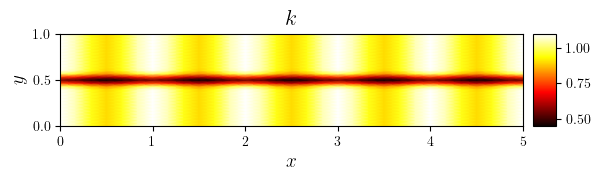

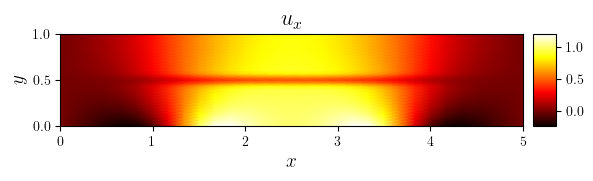

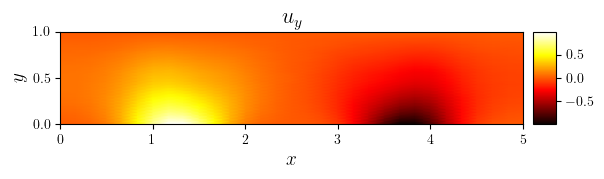

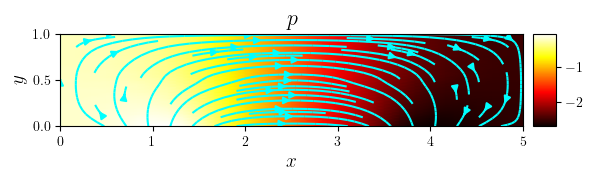

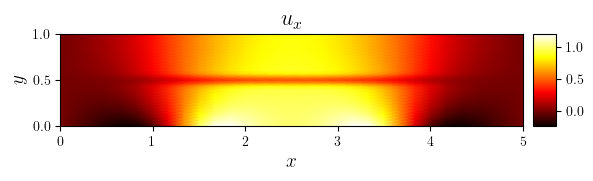

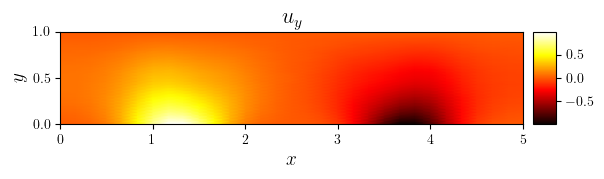

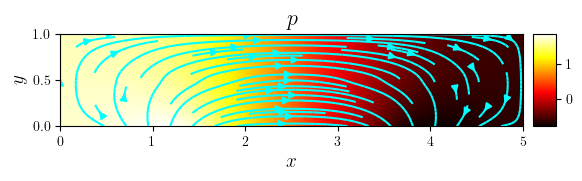

In [2]:
fig, ax = plot_colormap(k, title='$k$', x_label='$x$', y_label='$y$')

for up in (upMixed, upBlocked):
    u, p = up.split(collapse=True)
    ux, uy = extract_component_functions(('P', 1), u)
    fig, ax = plot_colormap(ux, title='$u_x$', x_label='$x$', y_label='$y$')
    fig, ax = plot_colormap(uy, title='$u_y$', x_label='$x$', y_label='$y$')
    fig, ax = plot_colormap(p, title='$p$', x_label='$x$', y_label='$y$') 
    plot_streamlines(fig, ax, (ux, uy), density=0.75, color='cyan')
    save_figure(f'p(x,y)_streamlines', thumbnail=(up is upBlocked))(fig)